# Aprendizaje online y gradiente descendente estocástico
## Definición del problema de estimación de parámetros

Se desean encontra los parámetros w_0 y w_1 del siguiente modelo de regresión entre las variables x y y:

$$y_i = w_1 x_i + w_0 + e_i$$

a partir de un conjunto de observaciones $\{d_i, x_i\}$, donde d_i es el valor real (observado), y_i es su aproximación usando el modelo de regresión descrito, y e_i es el error.

ya sabemos que 

La sumatoria de errores al cuadrado es definido como:

$$\text{SSE}(w_0, w_1) = \sum_i (d_i - y_i)^2$$

Si se tiene en cuenta que el error instantáneo se define como:

$$e_i = d_i - y_i$$

la ecuación anterior se puede reescribir como:

\begin{split} \text{SSE}(w_0, w_1) & = \sum_i (d_i - y_i)^2 \\ & = \sum_i e_i^2 \end{split}

## Con el aprendizaje batch (cálculo por medio del método del gradiente descendente)

\begin{split} \mathbf{w}_k & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1}) \\ & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \left( \sum_i e_i^2 \right) \end{split}

donde $\mathbf{w} = [w_0, w_1]$.

La ecuación anterior se puede reescribir como:

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \sum_i \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right)$$

que es calculando la derivada en cada punto específico de error. 

## Aprendizaje online
El aprendizaje online se obteiene al hacer una corrección de los parámetros de forma secuencial para cada punto $i$. El nombre se deriva del hecho de que los puntos

$$(x_i,y_i)$$

pueden presentarse al algoritmo como un stream de datos.

Es decir, la ecuación de corrección cambia a:

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right)$$

el proceso es el siguiente:

* Se computa el gradiente instantáneo para el punto i. (calcular derivada)

* Se realiza la corrección del vector de parámetros $\mathbf{w}_k$ con el gradiente para el punto i.

* Se pasa al siguiente punto (i = i + 1) y se rotorna al primer paso.

en este caso se necesitan las derivadas instantáneas las cuales son: 

\begin{split} \frac{\partial}{\partial w_0} e^2_i & = -2 e_i \\ \end{split}

\begin{split} \frac{\partial}{\partial w_1} e^2_i & = -2 e_i x_i \\ \end{split}





In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

In [4]:
#
# Datos del problema
#
x_sample = [
    0.6231,
    0.7460,
    0.1087,
    0.3654,
    0.3065,
    0.6886,
    0.4966,
    0.2618,
    0.7607,
    0.4424,
    0.7731,
]

y_sample = [
    1.6266,
    1.8508,
    0.9519,
    1.2828,
    1.2283,
    1.8722,
    1.4657,
    1.1097,
    1.7826,
    1.4267,
    1.8248,
]

In [5]:
#
# Sumatoria del error cuadrático o pérdida cuadrática
#
def sse(w0, w1):
    y_forecasts = [w0 + w1 * x_value for x_value in x_sample]
    errors = [y_true - y_forecast for y_true, y_forecast in zip(y_sample, y_forecasts)]
    squared_errors = [error ** 2 for error in errors]
    return sum(squared_errors)

In [6]:
def plot_contour():

    W0 = np.linspace(0.0, 0.8, 50)
    W1 = np.linspace(2.4, 3.2, 50)
    W0, W1 = np.meshgrid(W0, W1)
    F = sse(W0, W1)

    levels = [0, 0.2, 0.5, 0.75, 1, 2, 3, 5, 10, 20, 40, 60]

    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    ax.set_aspect("equal", "box")
    ax.contourf(W0, W1, F, cmap=cm.Greys, levels=levels, alpha=0.8)
    ax.contour(W0, W1, F, colors="gray", levels=levels)
    ax.grid()
    ax.set_xlabel("w0")
    ax.set_ylabel("w1")

In [7]:
def gradient(w0, w1, x_value, y_value):

    error = y_value - w0 - w1 * x_value
    #notese que las formulas salen explíticasa
    #como dervicadas analíticas.
    gradient_w0 = -2 * error
    gradient_w1 = -2 * error * x_value

    return gradient_w0, gradient_w1

Ecuación de mejora
$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right)$$

In [8]:
def improve(w0, w1, mu, x_value, y_value):

    gradient_w0, gradient_w1 = gradient(w0, w1, x_value, y_value)
    w0 = w0 - mu * gradient_w0
    w1 = w1 - mu * gradient_w1

    return w0, w1

 w0 = 0.2106
 w1 = 2.4542
SSE = 0.6276



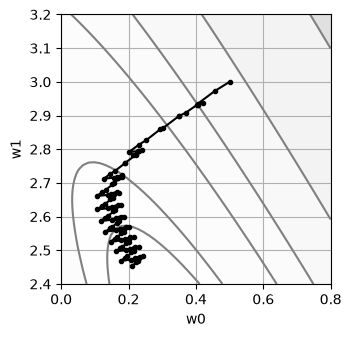

In [9]:
# proceso iterativo del aprendizaje online
#
# Punto de inicio
#
w0 = 0.5
w1 = 3.0

history = {
    "w0": [w0],
    "w1": [w1],
    "sse": [sse(w0, w1)],
}

mu = 0.03

for epoch in range(10):

    for x_value, y_value in zip(x_sample, y_sample):

        w0, w1 = improve(w0, w1, mu, x_value, y_value)

        history["w0"].append(w0)
        history["w1"].append(w1)
        history["sse"].append(sse(w0, w1))

print(" w0 = {:6.4f}\n w1 = {:6.4f}\nSSE = {:6.4f}\n".format(w0, w1, sse(w0, w1)))

plot_contour()
plt.plot(history["w0"], history["w1"], marker=".", color="black")
plt.show()

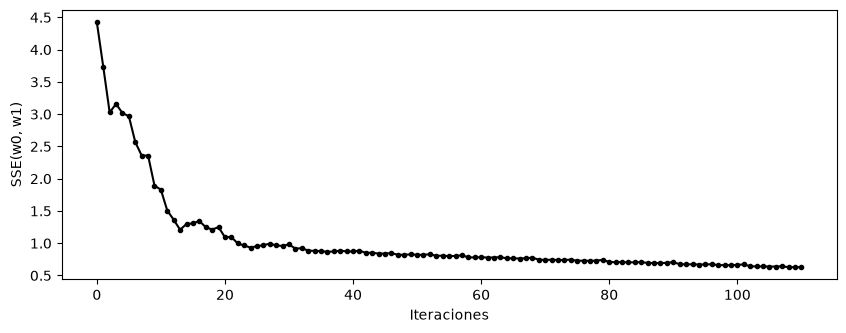

In [10]:
# reduccción de la suma del cuadrado de los residuos al incrementar 
#las iteraciones
plt.figure(figsize=(10, 3.5))
plt.plot(history["sse"], ".-k")
plt.xlabel("Iteraciones")
plt.ylabel("SSE(w0, w1)")
plt.show()

El descenso por gradiente online se diferencia del descednso por gradiente tradicional en la cantidad de datos que procesa para realizar una sola actualización de los parámetros. 

Batch Gradient Descent (Tradicional): Espera a procesar TODO el conjunto de datos de entrenamiento para calcular el gradiente global y hacer una sola actualización de los pesos. Por eso es es que el cálculo del vector gradiente se hace sobre la suma del cuadrado de los residuos

\begin{split} \mathbf{w}_k & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \text{SSE}(\mathbf{w}_{k-1}) \\ & = \mathbf{w}_{k-1} - \mu \frac{\partial}{\partial \mathbf{w}} \left( \sum_i e_i^2 \right) \end{split}

En su lugar, Online Gradient Descent: Procesa UN SOLO dato a la vez. Inmediatamente calcula la pérdida, actualiza los pesos y descarta (o pasa al siguiente) ese dato. Como es de a un solo dato por ello es que pueden llegar los demás de a uno. Como online

Datos masivos o en Streaming: Si tus datos no caben en la memoria RAM o llegan constantemente en tiempo real (por ejemplo, clics de usuarios en una web), el enfoque Online es la única opción viable, ya que el modelo "aprende sobre la marcha".



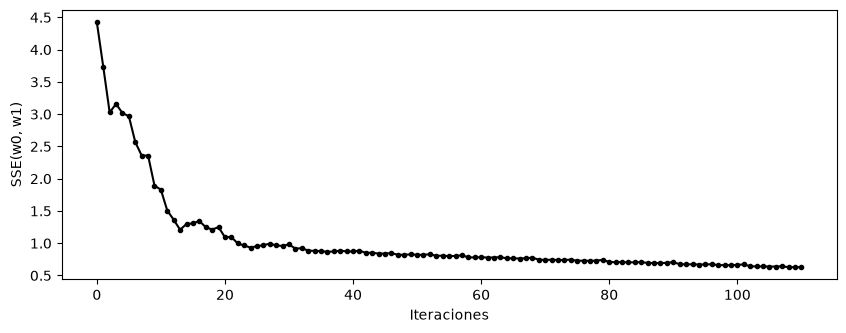

In [11]:
# Visualización del historial de SSE
plt.figure(figsize=(10, 3.5))
plt.plot(history["sse"], ".-k")
plt.xlabel("Iteraciones")
plt.ylabel("SSE(w0, w1)")
plt.show()

## Gradiente descendente estocástico
El método de gradiente descendente estocástico es el método de aprendizaje online (el anterior) en que los patrones se recorren de manera aleatoria. 

 w0 = 0.2194
 w1 = 2.4605
SSE = 0.6260



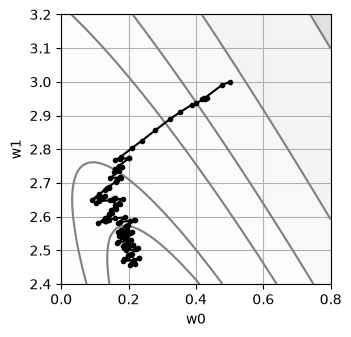

In [ ]:
#
# Punto de inicio
#
w0 = 0.5
w1 = 3.0

history = {
    "w0": [w0],
    "w1": [w1],
    "sse": [sse(w0, w1)],
}

mu = 0.03

n_samples = len(x_sample)

for epoch in range(10):

    # Acá notese que se toman las muestras de manera aleatoria, sin reemplazo,
    #  para que no se repitan en la misma iteración pero se garantiza que se 
    # recorran todos los puntos a diferencia del online
    # que se hace de manera secuencial.
    for n in np.random.choice(n_samples, n_samples, replace=False):

        w0, w1 = improve(w0, w1, mu, x_sample[n], y_sample[n])

        history["w0"].append(w0)
        history["w1"].append(w1)
        history["sse"].append(sse(w0, w1))

print(" w0 = {:6.4f}\n w1 = {:6.4f}\nSSE = {:6.4f}\n".format(w0, w1, sse(w0, w1)))

# ver la curvas de nivel. 
plot_contour()
plt.plot(history["w0"], history["w1"], marker=".", color="black");

In [ ]:
#función para haacer una selección de manera aleatoria de los elementos de un arreglo sin reemplazo
np.random.choice(10,10,replace=False)

array([1, 4, 7, 9, 5, 6, 2, 3, 0, 8])

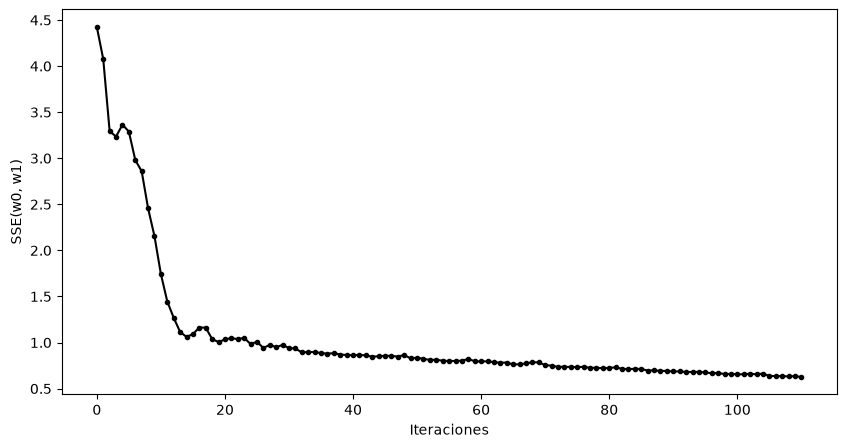

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history["sse"], ".-k")
plt.xlabel("Iteraciones")
plt.ylabel("SSE(w0, w1)")
plt.show()

Nota: 
El aprendizaje batch converge más rapidamente pero converge en púntos de mínimo local lo cúal puede verse con el método SSE

Mientras que el gradiente descendente estocástico puede saltar estos mínimos locales saltando de diferentes puntos

# Aprendizaje Minibatch
## Definición del problema de estimación de parámetros y función de pérdida. 

Se desean encontra los parámetros w_0 y w_1 del siguiente modelo de regresión entre las variables x y y:

$$y_i = w_1 x_i + w_0 + e_i$$

a partir de un conjunto de observaciones $\{d_i, x_i\}$, donde d_i es el valor real (observado), y_i es su aproximación usando el modelo de regresión descrito (valor ajustado), y e_i es el error.

Error instantáneo:

$$e_i = d_i - y_i \text{real - ajustado}$$ 

Sumatoria del error cuadrático instantáneo:

$$\begin{split} \text{SSE}(w_0, w_1) & = \sum_i (d_i - y_i)^2 \\ & = \sum_i e_i^2 \end{split}$$

## Versiones del método del gradiente

Aprendizaje Online: Tomando el error puntual donde el valor de pendiente e intercepto son diferentes. 

$$\mathbf{w}_k = \mathbf{w}_{k-1} - \mu \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right)$$

Aprendizaje Batch: En este se calcula la derivada de todo el error de tal manera ue se evalua el data set con los mismos valores de pendiente e intercepto. 

\begin{split} \mathbf{w}_k & = \mathbf{w}_{k-1} - \mu \sum_i \left( \frac{\partial}{\partial \mathbf{w}} e_i^2 \right) \end{split}

## Minibatch

Para conjuntos de datos muy grandes el aprendizaje batch es muy costoso computacionalmente ya que deben recorrerse todos los datos, mientras que el aprendizaje online es muy lento en converger. Es en este caso, donde se toma un punto intermedio:

* El conjunto de datos se divide en varios subconjuntos.

* Se ordenan aleatoriamente los subconjuntos de datos y luego se recorren uno a uno, tal como en el caso del gradiente descendente estocástico.

* Para el subconjunto actual, se computa el gradiente neto (tal como en el caso del aprendizaje batch) y se corrigen los parámetros.

* Se repite nuevamente el proceso hasta que el algoritmo converga.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

In [ ]:
#
# Dataset
#
x_sample = [
    0.1087,
    0.2698,
    0.3765,
    0.2146,
    0.9155,
    0.0246,
    0.0221,
    0.8632,
    0.6460,
    0.2092,
    0.8567,
    0.1591,
    0.9647,
    0.6231,
    0.7460,
    0.3654,
    0.3065,
    0.6886,
    0.4966,
    0.2008,
    0.2618,
    0.7607,
    0.1563,
    0.4424,
    0.7731,
]

y_sample = [
    0.9519,
    1.1237,
    1.2360,
    1.0526,
    2.0743,
    0.7906,
    0.7603,
    2.0533,
    1.6887,
    1.0563,
    2.0991,
    0.8953,
    2.1917,
    1.6266,
    1.8508,
    1.2828,
    1.2283,
    1.8722,
    1.4657,
    1.0418,
    1.1097,
    1.7826,
    0.9711,
    1.4267,
    1.8248,
]

In [ ]:
#
# Función auxiliar para computar el SSE
#
#
# Sumatoria del error cuadrático o pérdida cuadrática
#
def sse(w0, w1):
    #pronósticos para cada valor de x en la muestra
    y_forecasts = [w0 + w1 * x_value for x_value in x_sample]

    # residuales
    errors = [y_true - y_forecast for y_true, y_forecast in zip(y_sample, y_forecasts)]

    # errores al cuadrado
    squared_errors = [error ** 2 for error in errors]

    # suma de los errores al cuadrado
    return sum(squared_errors)

In [ ]:
#
# Función auxililar para graficar el contorno
#
def plot_contour():

    W0 = np.linspace(0.0, 2.0, 50)
    W1 = np.linspace(1.5, 3.2, 50)
    W0, W1 = np.meshgrid(W0, W1)
    F = sse(W0, W1)

    levels = [0, 0.2, 0.5, 0.75, 1, 2, 3, 5, 10, 20, 40, 60, 80, 100, 120]

    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    ax.set_aspect("equal", "box")
    ax.contourf(W0, W1, F, cmap=cm.Greys, levels=levels, alpha=0.8)
    ax.contour(W0, W1, F, colors="gray", levels=levels)
    ax.grid()
    ax.set_xlabel("w0")
    ax.set_ylabel("w1")

In [ ]:
#
# Esta es el mismo computo que el empleado en el
# método batch.
#
def gradient(w0, w1, indices):

    x_batch = x_sample[indices]
    y_batch = y_sample[indices]

    y_forecasts = [w0 + w1 * x_value for x_value in x_batch]

    errors = [y_true - y_forecast for y_true, y_forecast in zip(y_batch, y_forecasts)]

    gradient_w0 = -2 * sum(errors)
    gradient_w1 = -2 * sum([error * x_value for error, x_value in zip(errors, x_batch)])

    return gradient_w0, gradient_w1

In [ ]:
def improve(w0, w1, mu, indices):

    gradient_w0, gradient_w1 = gradient(w0, w1, indices)

    w0 = w0 - mu * gradient_w0
    w1 = w1 - mu * gradient_w1

    return w0, w1

In [ ]:
n_batches = 5
batch_indices = np.array_split(np.array(range(len(x_sample))), n_batches)
batch_indices

In [ ]:
#
# Punto de inicio
#
w0 = 0.5
w1 = 3.0

history = {
    "w0": [w0],
    "w1": [w1],
    "sse": [sse(w0, w1)],
}

mu = 0.05

x_sample = np.array(x_sample)
y_sample = np.array(y_sample)

for epoch in range(10):

    for i_group in np.random.choice(n_batches, n_batches, replace=False):

        indices = list(batch_indices[i_group])

        w0, w1 = improve(w0, w1, mu, indices)

        history["w0"].append(w0)
        history["w1"].append(w1)
        history["sse"].append(sse(w0, w1))

print(" w0 = {:6.4f}\n w1 = {:6.4f}\nSSE = {:6.4f}\n".format(w0, w1, sse(w0, w1)))

plot_contour()
plt.plot(history["w0"], history["w1"], marker=".", color="black")
plt.show()

In [ ]:
plt.figure(figsize=(10, 3.5))
plt.plot(history["sse"], ".-k")
plt.xlabel("Iteraciones")
plt.ylabel("SSE(w0, w1)")
plt.show()

min 1:38 regla delta generalizada y algoritmos con supermemoria. 